# Гиперпараметры и валидация модели

На одной из первых лекций мы увидели базовый рецепт применения модели обучения с учителем:

1. Выбрать класс модели.
2. Выбрать гиперпараметры модели.
3. Обучить модель на тренировочных данных.
4. Использовать модель для предсказания меток для новых данных.

Первые два пункта — выбор модели и выбор гиперпараметров — пожалуй, важнейшая часть эффективного применения этих инструментов и методов. Чтобы сделать осознанный выбор, нам нужен способ *проверить*, насколько хорошо наша модель и её гиперпараметры подходят данным. Звучит просто, но здесь есть несколько ловушек, которых нужно избегать.

## Как думать о валидации модели

В принципе, валидация модели очень проста: после выбора модели и её гиперпараметров мы можем оценить её эффективность, применив её к части тренировочных данных и сравнив предсказания с известными значениями.

В этом разделе сначала будет показан наивный подход к валидации модели и объяснено, почему он не работает, а затем — использование отложенных выборок и кросс-валидации для более надёжной оценки модели.

### Неправильный способ валидации модели

Давайте продемонстрируем наивный подход к валидации на данных Iris, которые мы уже видели в предыдущем разделе. Начнём с загрузки данных:

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target


Теперь выберем модель и гиперпараметры. Здесь мы используем классификатор *k* ближайших соседей с `n_neighbors=1`. Это очень простая и интуитивная модель, которая говорит: «метка неизвестной точки совпадает с меткой ближайшей к ней точки из обучающей выборки»:

In [2]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)


Затем мы обучаем модель и используем её для предсказания меток для данных, метки которых нам уже известны:

In [3]:
model.fit(X, y)
y_pred = model.predict(X)


Наконец, вычислим долю правильно размеченных точек:

In [4]:
from sklearn.metrics import accuracy_score

accuracy_score(y, y_pred)


1.0

Мы получаем значение accuracy, равное 1.0, то есть модель правильно размечает 100% точек! Но действительно ли это измеряет ожидаемую точность? Неужели мы нашли модель, которая будет верна в 100% случаев?

Как вы уже, вероятно, поняли, ответ — нет. В этом подходе есть фундаментальная ошибка: *модель обучается и оценивается на одних и тех же данных*. Более того, метод ближайших соседей — это оцениватель, основанный на экземплярах (*instance-based estimator*): он просто хранит обучающие данные и предсказывает метки, сравнивая новые точки с уже сохранёнными. Поэтому, если не создавать искусственные исключения, он будет показывать 100% точности почти всегда.

### Правильный способ валидации модели: отложенные выборки

Что же делать? Более реалистичное представление о качестве модели можно получить с помощью *отложенной выборки* (*holdout set*): мы откладываем часть данных и не используем её при обучении, а затем проверяем качество модели именно на ней.

![alt text](https://yastatic.net/s3/education-portal/media/image_3_fe61c97b25.webp)

Такое разбиение можно сделать с помощью утилиты `train_test_split` из Scikit-Learn:

In [5]:
from sklearn.model_selection import train_test_split

# Разделим данные так, чтобы в каждом наборе было по 50%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.5,
    random_state=0,
)

# Обучим модель на одной части данных
model.fit(X_train, y_train)

# Оценим модель на второй части данных
y_test_pred = model.predict(X_test)
accuracy_score(y_test, y_test_pred)


0.9066666666666666

Здесь мы получаем гораздо более разумный результат: классификатор ближайших соседей показывает около 90% точности на этой отложенной выборке. Отложенная выборка похожа на неизвестные данные, потому что модель *не видела* её во время обучения.

### Валидация модели с помощью кросс-валидации

Один из недостатков отложенной выборки состоит в том, что часть данных теряется для обучения модели. В предыдущем примере половина набора данных вообще не участвовала в обучении! Это не лучший вариант, особенно если исходный обучающий набор мал.

Один из способов обойти это — использовать *кросс-валидацию* (*cross-validation*): выполнить серию обучений, в которой каждый поднабор данных по очереди используется и как обучающая выборка, и как валидационная. Визуально это выглядит примерно так:

Здесь мы выполняем две проверки, попеременно используя каждую половину данных как отложенную выборку. Используя предыдущее разбиение, это можно реализовать так:

In [6]:
y_test_pred = model.fit(X_train, y_train).predict(X_test)
y_train_pred = model.fit(X_test, y_test).predict(X_train)

accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)


(0.96, 0.9066666666666666)

На выходе получаются две оценки accuracy, которые можно объединить — например, взять среднее — и получить более надёжную оценку общей производительности модели.

Эта конкретная форма кросс-валидации называется *двухблочной кросс-валидацией* (*two-fold cross-validation*): мы разделили данные на две части и по очереди использовали каждую как валидационный набор.

Эту идею можно развить и использовать большее число прогонов и большее число блоков (*folds*). Например, следующий рисунок показывает пятиблочную кросс-валидацию:

![alt text](https://media.geeksforgeeks.org/wp-content/uploads/20250912171723027927/train_test_split.webp)

Здесь мы делим данные на пять групп и по очереди используем каждую из них для оценки модели, обученной на остальных четырёх пятых данных. Делать это вручную довольно утомительно, поэтому воспользуемся современным API из `sklearn.model_selection`. Для быстрой оценки одной метрики подходит `cross_val_score`, а для более содержательной диагностики — `cross_validate`, который возвращает и обучающие оценки, и время обучения:

In [23]:
from sklearn.model_selection import cross_validate
import pandas as pd

cv_results = cross_validate(
    model,
    X,
    y,
    cv=5,
    return_train_score=True,
    n_jobs=-1,
)

pd.DataFrame(cv_results).round(3)


,fit_time,score_time,test_score,train_score
0,0.005,0.003,0.966,0.945
1,0.004,0.002,0.946,0.948
2,0.004,0.002,0.910,0.955
3,0.003,0.002,0.873,0.957
4,0.005,0.003,0.938,0.952


Повторяя валидацию на разных поднаборах данных, мы получаем ещё лучшее представление о качестве алгоритма.

В Scikit-Learn реализовано несколько полезных схем кросс-валидации, которые удобны в разных ситуациях; они доступны через итераторы в модуле `model_selection`. Например, можно довести идею до предела и взять число блоков равным числу точек данных: в каждом прогоне мы обучаемся на всех точках, кроме одной. Такой вид кросс-валидации называется *leave-one-out cross-validation* и используется так:

In [9]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

scores = cross_val_score(model, X, y, cv=LeaveOneOut())
scores


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Поскольку у нас 150 наблюдений, метод leave-one-out даёт оценки для 150 прогонов, причём значение score равно либо 1.0 (успешное предсказание), либо 0.0 (ошибка). Если взять среднее, получим оценку уровня ошибки:

In [10]:
scores.mean()


np.float64(0.96)

Другие схемы кросс-валидации используются аналогично. Чтобы увидеть, что именно доступно в Scikit-Learn, можно исследовать подмодуль `sklearn.model_selection` в IPython или обратиться к [онлайн-документации Scikit-Learn по кросс-валидации](https://scikit-learn.org/stable/modules/cross_validation.html).

## Выбор лучшей модели

Теперь, когда мы разобрали основы валидации и кросс-валидации, можно чуть глубже погрузиться в выбор модели и подбор гиперпараметров. Это один из важнейших аспектов практики машинного обучения, но во вводных туториалах его часто пролистывают.

Ключевой вопрос здесь такой: если наш оцениватель работает плохо, как двигаться дальше? Возможны несколько ответов:

- использовать более сложную / более гибкую модель;
- использовать более простую / менее гибкую модель;
- собрать больше обучающих примеров;
- собрать больше данных, чтобы добавить признаки для каждого примера.

Ответ нередко оказывается контринтуитивным. Иногда более сложная модель даёт худший результат, а увеличение числа обучающих примеров не улучшает его вовсе. Умение понять, *какие именно шаги действительно улучшат модель*, отличает сильных практиков машинного обучения от слабых.

### Компромисс между смещением и дисперсией

По сути вопрос о «лучшей модели» — это поиск удачной точки в компромиссе между *смещением* (*bias*) и *дисперсией* (*variance*). Посмотрите на следующий рисунок, где показаны две регрессионные аппроксимации одного и того же набора данных:

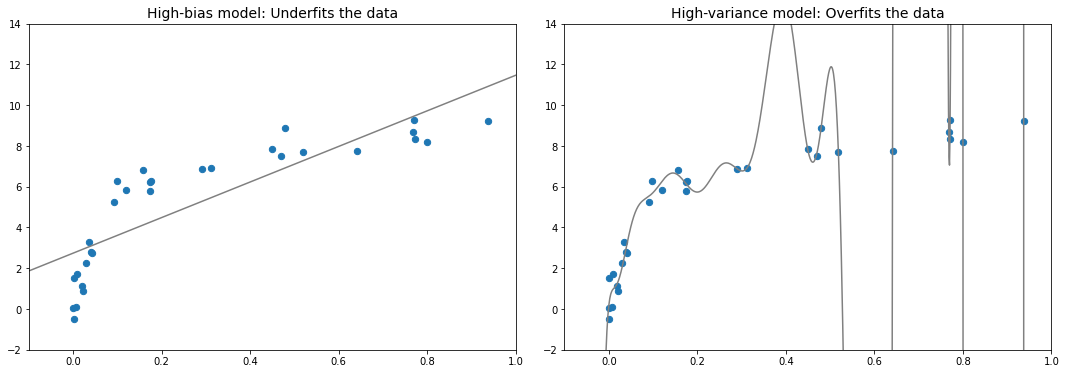

Очевидно, что ни одна из этих моделей не подходит данным особенно хорошо, но ошибаются они по-разному.

Модель слева пытается провести через данные прямую. Поскольку сами данные по своей природе сложнее прямой линии, такая модель никогда не сможет хорошо описать этот набор. Говорят, что она *недообучается* (*underfit*): ей не хватает гибкости, чтобы учесть все особенности данных. Иными словами, у модели высокое смещение.

Модель справа, напротив, пытается подогнать полином высокой степени. У неё достаточно гибкости, чтобы почти идеально описать мелкие детали обучающих данных, но её точная форма, похоже, отражает скорее конкретный шум в данных, чем внутренние свойства процесса, породившего эти данные.

Такую модель называют *переобученной* (*overfit*): её гибкость настолько велика, что она начинает учитывать не только истинную структуру данных, но и случайные ошибки. Иначе говоря, у модели высокая дисперсия.

Посмотрим на это под другим углом: что произойдёт, если использовать эти две модели для предсказания значения `y` на новых данных? На следующем рисунке красные / более светлые точки — это данные, исключённые из обучающей выборки:

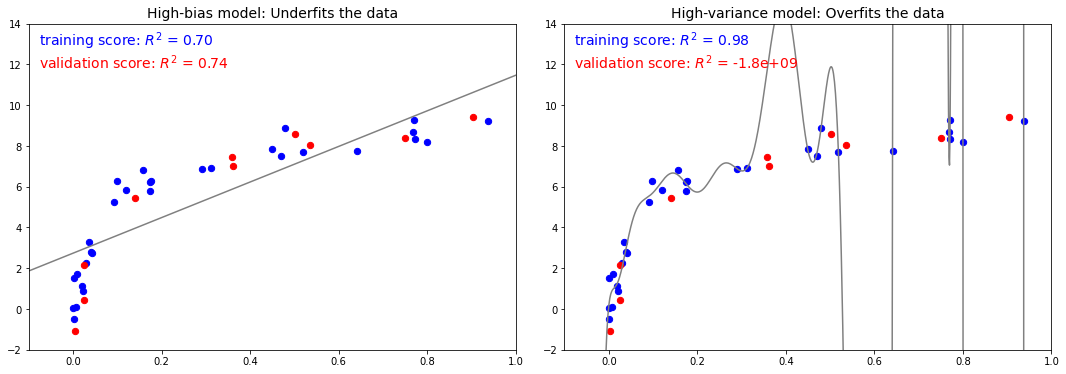

Используемая здесь метрика — это $R^2$ (*coefficient of determination*, коэффициент детерминации), который измеряет, насколько хорошо модель работает по сравнению с простым средним целевых значений. $R^2 = 1$ означает идеальное совпадение, $R^2 = 0$ — что модель не лучше простого среднего, а отрицательные значения означают ещё худшие модели. Из оценок этих двух моделей можно сделать обобщение:

- Для моделей с высоким смещением качество на валидационной выборке похоже на качество на обучающей выборке.
- Для моделей с высокой дисперсией качество на валидационной выборке заметно хуже, чем на обучающей.

Если представить, что мы умеем регулировать сложность модели, то ожидали бы, что обучающая и валидационная оценки будут вести себя примерно так:

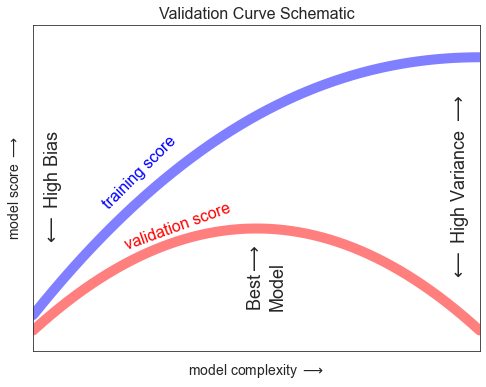

Этот график часто называют *кривой валидации* (*validation curve*). Из него видно несколько важных вещей:

- Обучающая оценка везде выше валидационной. Обычно так и бывает: модель лучше подходит к данным, которые уже видела, чем к тем, которых не видела.
- При очень низкой сложности модели (модель с высоким смещением) обучающие данные недообучены, поэтому модель плохо предсказывает и обучающие, и новые данные.
- При очень высокой сложности модели (модель с высокой дисперсией) обучающие данные переобучены: модель отлично предсказывает обучающие данные, но проваливается на новых.
- Для некоторого промежуточного значения кривая валидации достигает максимума. Этот уровень сложности и даёт разумный компромисс между смещением и дисперсией.

Способ регулировки сложности зависит от конкретной модели, упоминали на прошлых лекциях.

### Кривые валидации в Scikit-Learn

Давайте посмотрим на пример использования кросс-валидации для вычисления кривой валидации для класса моделей. Здесь мы используем полиномиальную регрессию: это обобщённая линейная модель, в которой степень полинома — настраиваемый параметр. Например, полином первой степени даёт прямую линию; для параметров модели $a$ и $b$:

$$ y = ax + b $$

Полином третьей степени задаёт кубическую кривую; для параметров $a, b, c, d$:

$$ y = ax^3 + bx^2 + cx + d $$

Эту идею можно обобщить на любое число полиномиальных признаков. В Scikit-Learn это удобно реализовать как простую линейную регрессию, объединённую с препроцессором полиномиальных признаков. Мы используем конвейер (*pipeline*), чтобы связать эти операции вместе:

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def polynomial_regression(degree: int = 2, **kwargs):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(**kwargs),
    )


Теперь создадим данные, на которых будем обучать модель:

In [12]:
import numpy as np


def make_data(n_samples: int, err: float = 1.0, seed: int = 1):
    # Случайно сэмплируем данные
    rng = np.random.default_rng(seed)
    X = (rng.random((n_samples, 1))) ** 2
    y = 10 - 1.0 / (X.ravel() + 0.1)

    if err > 0:
        y += err * rng.standard_normal(n_samples)

    return X, y


X, y = make_data(40)


Теперь можно визуализировать данные вместе с полиномиальными аппроксимациями нескольких степеней:

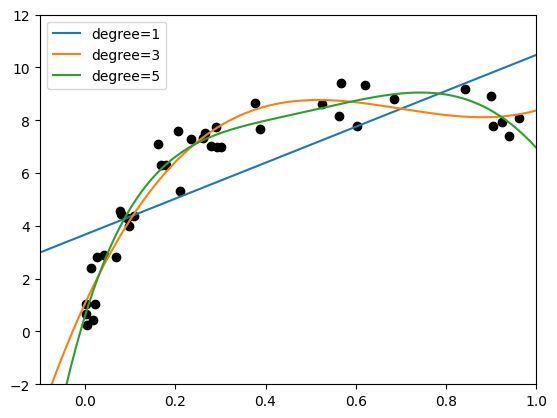

In [13]:
import matplotlib.pyplot as plt

X_test = np.linspace(-0.1, 1.1, 500)[:, None]

fig, ax = plt.subplots()
ax.scatter(X.ravel(), y, color="black")

for degree in [1, 3, 5]:
    y_test = polynomial_regression(degree).fit(X, y).predict(X_test)
    ax.plot(X_test.ravel(), y_test, label=f"degree={degree}")

ax.set(
    xlim=(-0.1, 1.0),
    ylim=(-2, 12),
)
ax.legend(loc="best")


Здесь ручка, управляющая сложностью модели, — это степень полинома, которая может быть любым неотрицательным целым числом. Полезный вопрос: какая степень полинома даёт подходящий компромисс между смещением (*under-fitting*) и дисперсией (*over-fitting*)?

Продвинуться здесь помогает визуализация кривой валидации для этой модели и этих данных. Это легко сделать с помощью функции `validation_curve`, предоставляемой Scikit-Learn. Если передать ей модель, данные, имя параметра и диапазон значений, она автоматически вычислит и обучающую, и валидационную оценки во всём диапазоне:

[(-0.1, 1.05),
 Text(0.5, 0, 'degree'),
 Text(0, 0.5, 'R² score'),
 Text(0.5, 1.0, 'Validation curve')]

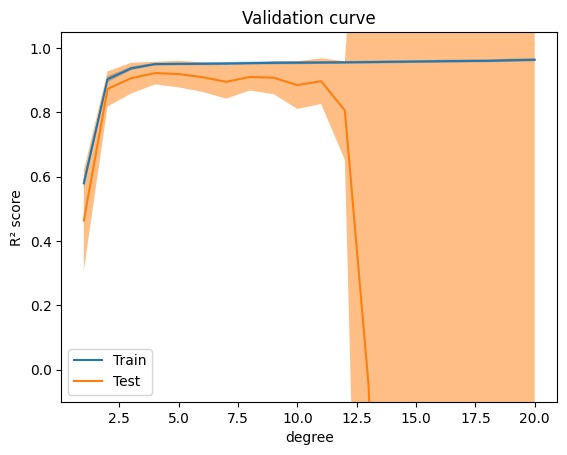

In [14]:
from sklearn.model_selection import ValidationCurveDisplay

degree = np.arange(0, 21)

fig, ax = plt.subplots()
ValidationCurveDisplay.from_estimator(
    polynomial_regression(),
    X,
    y,
    param_name="polynomialfeatures__degree",
    param_range=degree,
    cv=7,
    scoring="r2",
    n_jobs=-1,
    score_type="both",
    std_display_style="fill_between",
    ax=ax,
)

ax.set(
    ylim=(-0.1, 1.05),
    xlabel="degree",
    ylabel="R² score",
    title="Validation curve",
)


Этот график показывает именно то качественное поведение, которого мы ожидали: обучающая оценка везде выше валидационной; обучающая оценка монотонно растёт с увеличением сложности модели; а валидационная оценка достигает максимума и затем падает, когда модель начинает переобучаться.

Из кривой валидации видно, что оптимальный компромисс между смещением и дисперсией здесь достигается для полинома третьей степени. Можно вычислить эту аппроксимацию и показать её поверх исходных данных:

(np.float64(-0.047294792794817256),
 np.float64(1.0098997525915363),
 np.float64(-0.19228482648984158),
 np.float64(9.85014642163149))

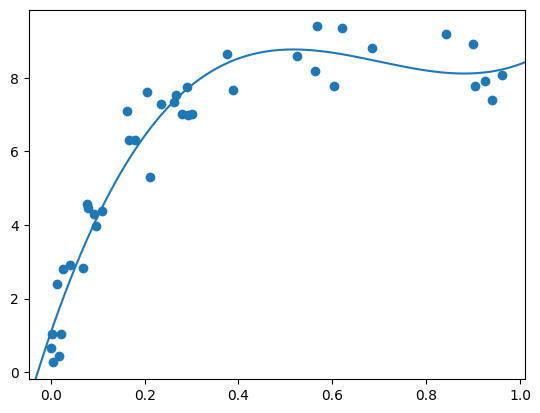

In [15]:
fig, ax = plt.subplots()
ax.scatter(X.ravel(), y)

limits = ax.axis()
y_test = polynomial_regression(3).fit(X, y).predict(X_test)
ax.plot(X_test.ravel(), y_test)
ax.axis(limits)


Заметьте: чтобы найти оптимальную модель, нам вообще не обязательно было вычислять обучающую оценку. Но анализ связи между обучающей и валидационной оценками даёт полезное понимание того, как именно ведёт себя модель.

## Кривые обучения

Один из важных аспектов сложности модели в том, что оптимальная модель обычно зависит от размера обучающего набора. Например, давайте сгенерируем новый набор данных, в котором точек в пять раз больше:

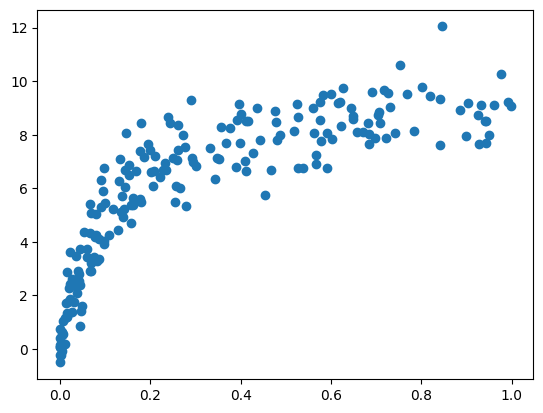

In [16]:
X2, y2 = make_data(200)

fig, ax = plt.subplots()
ax.scatter(X2.ravel(), y2)


Повторим предыдущий код, чтобы построить кривую валидации для этого большего набора данных; для сравнения поверх неё нанесём и предыдущий результат:

[(-0.1, 1.05),
 Text(0.5, 0, 'degree'),
 Text(0, 0.5, 'R² score'),
 Text(0.5, 1.0, 'Validation curves by dataset size')]

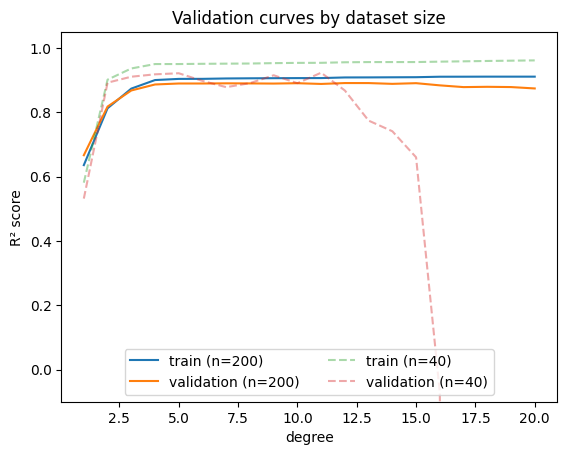

In [17]:
from sklearn.model_selection import validation_curve

degree = np.arange(0, 21)

train_score_small, val_score_small = validation_curve(
    polynomial_regression(),
    X,
    y,
    param_name="polynomialfeatures__degree",
    param_range=degree,
    cv=7,
    scoring="r2",
    n_jobs=-1,
)

train_score_large, val_score_large = validation_curve(
    polynomial_regression(),
    X2,
    y2,
    param_name="polynomialfeatures__degree",
    param_range=degree,
    cv=7,
    scoring="r2",
    n_jobs=-1,
)

fig, ax = plt.subplots()

ax.plot(degree, np.median(train_score_large, axis=1), label="train (n=200)")
ax.plot(degree, np.median(val_score_large, axis=1), label="validation (n=200)")
ax.plot(
    degree,
    np.median(train_score_small, axis=1),
    linestyle="--",
    alpha=0.4,
    label="train (n=40)",
)
ax.plot(
    degree,
    np.median(val_score_small, axis=1),
    linestyle="--",
    alpha=0.4,
    label="validation (n=40)",
)

ax.legend(loc="lower center", ncols=2)
ax.set(
    ylim=(-0.1, 1.05),
    xlabel="degree",
    ylabel="R² score",
    title="Validation curves by dataset size",
)


Сплошные линии показывают новый результат, а бледные пунктирные — результат для предыдущего, меньшего набора данных. Из кривой валидации ясно, что больший набор поддерживает гораздо более сложную модель: максимум здесь, вероятно, приходится примерно на степень 6, но даже модель степени 20 уже не выглядит серьёзно переобученной — обучающая и валидационная оценки остаются очень близки.

Значит, на поведение кривой валидации влияют не один, а два ключевых входа: сложность модели и число обучающих точек. Часто полезно изучить поведение модели как функцию размера обучающего набора, то есть обучать модель на всё больших подмножествах данных. График зависимости обучающей / валидационной оценки от размера обучающего набора называется *кривой обучения* (*learning curve*).

В общем случае от кривой обучения мы ожидаем следующее:

- Модель фиксированной сложности будет переобучаться на маленьком наборе данных: обучающая оценка будет сравнительно высокой, а валидационная — сравнительно низкой.
- Та же модель будет недообучаться на большом наборе данных: обучающая оценка снизится, а валидационная повысится.
- За исключением случайности модель не должна давать лучшую оценку на валидации, чем на обучении: значит, кривые будут сближаться, но не пересекаться.

С учётом этого можно ожидать, что кривая обучения будет качественно выглядеть примерно так:

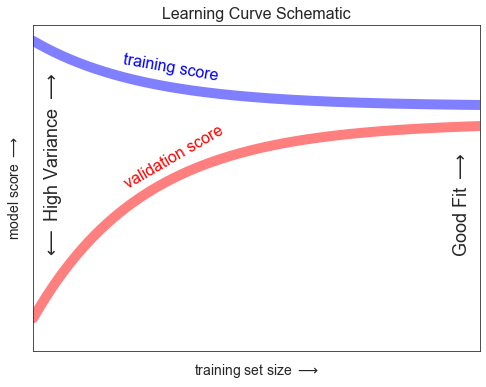

Главная особенность кривой обучения — сходимость к некоторому значению score по мере роста числа обучающих примеров. И особенно важно вот что: когда для конкретной модели эта сходимость уже достигнута, добавление новых обучающих данных больше не поможет. Тогда улучшить качество можно только одним способом — взять другую, чаще всего более сложную, модель.

### Кривые обучения в Scikit-Learn

Scikit-Learn предоставляет удобную функцию для вычисления таких кривых обучения. Здесь мы построим кривые для исходного набора данных для полинома второй степени и полинома девятой степени:

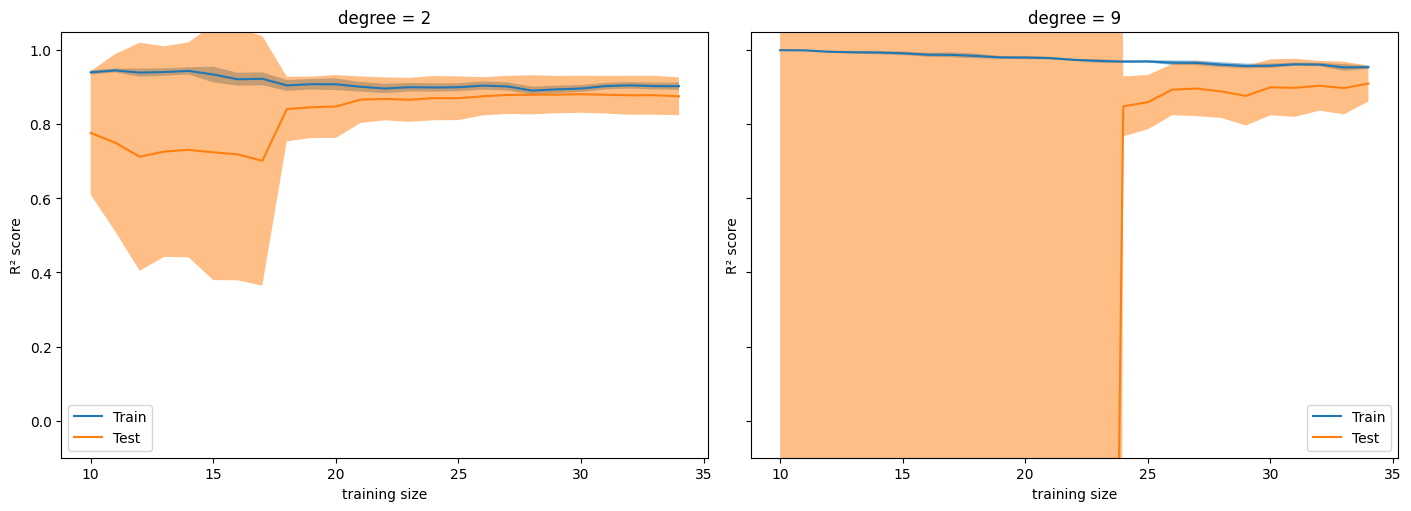

In [18]:
from sklearn.model_selection import LearningCurveDisplay

fig, axes = plt.subplots(ncols=2, figsize=(14, 5), sharey=True, constrained_layout=True)

for ax, degree in zip(axes, [2, 9]):
    LearningCurveDisplay.from_estimator(
        polynomial_regression(degree),
        X,
        y,
        cv=7,
        scoring="r2",
        train_sizes=np.linspace(0.3, 1.0, 25),
        n_jobs=-1,
        score_type="both",
        std_display_style="fill_between",
        ax=ax,
    )
    ax.set(
        title=f"degree = {degree}",
        xlabel="training size",
        ylabel="R² score",
        ylim=(-0.1, 1.05),
    )

axes[0].legend(loc="best")


Это полезная диагностика, потому что она наглядно показывает, как модель реагирует на увеличение объёма обучающих данных. В частности, если ваша кривая обучения уже сошлась (то есть обучающая и валидационная кривые уже близки друг к другу), добавление новых данных заметно не улучшит аппроксимацию. Именно такую ситуацию мы видим на левой панели для модели второй степени.

Единственный способ повысить итоговый уровень качества — перейти к другой, обычно более сложной, модели. Это видно на правой панели: переход к заметно более сложной модели повышает уровень сходимости (его показывает пунктирная линия), но ценой большей дисперсии модели (на что указывает разница между обучающей и валидационной оценками). Если добавить ещё больше данных, кривая обучения для более сложной модели в конце концов тоже сойдётся.

Построение кривой обучения для вашей конкретной модели и конкретного набора данных помогает принимать именно такие решения о том, как двигаться дальше и улучшать анализ.

В актуальных версиях Scikit-Learn такие графики удобно строить через `LearningCurveDisplay`, что делает код короче и прозрачнее.

## Валидация на практике: Grid Search

Предыдущее обсуждение должно было дать вам интуицию относительно компромисса между смещением и дисперсией и его зависимости от сложности модели и размера обучающего набора. На практике у моделей обычно больше одного «регулятора», и графики кривых валидации и обучения превращаются из линий в многомерные поверхности. В таких случаях визуализация становится неудобной, и нам проще просто найти ту конкретную модель, которая максимизирует валидационную оценку.

Scikit-Learn предоставляет для этого автоматизированные инструменты в модуле *grid search*. Ниже пример поиска оптимальной полиномиальной модели. Мы исследуем трёхмерную сетку параметров: степень полинома, флаг необходимости подгонять свободный член (*fit_intercept*) и флаг нормализации задачи (*normalize*). Это можно задать с помощью мета-оценивателя `GridSearchCV` из Scikit-Learn:

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "polynomialfeatures__degree": np.arange(21),
    "polynomialfeatures__include_bias": [False, True],
    "linearregression__fit_intercept": [True, False],
}

grid = GridSearchCV(
    estimator=polynomial_regression(),
    param_grid=param_grid,
    cv=7,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True,
)


Обратите внимание: как и обычный оцениватель, этот объект пока ещё не применялся ни к каким данным. Вызов метода `fit()` обучит модель в каждой точке сетки и будет отслеживать оценки по мере работы:

In [20]:
grid.fit(X, y);


/home/prosto-petro/PROJECTS/envs/shad_env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
14 fits failed out of a total of 588.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "/home/prosto-petro/PROJECTS/envs/shad_env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/prosto-petro/PROJECTS/envs/shad_env/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/prosto-petro/PROJECT

После обучения можно запросить лучшие параметры:

In [21]:
{
    "best_params": grid.best_params_,
    "best_cv_r2": round(grid.best_score_, 3),
}


{'best_params': {'linearregression__fit_intercept': False,
  'polynomialfeatures__degree': np.int64(4),
  'polynomialfeatures__include_bias': True},
 'best_cv_r2': np.float64(0.922)}

Наконец, при желании можно взять лучшую модель и показать, как она аппроксимирует наши данные, используя уже знакомый код:

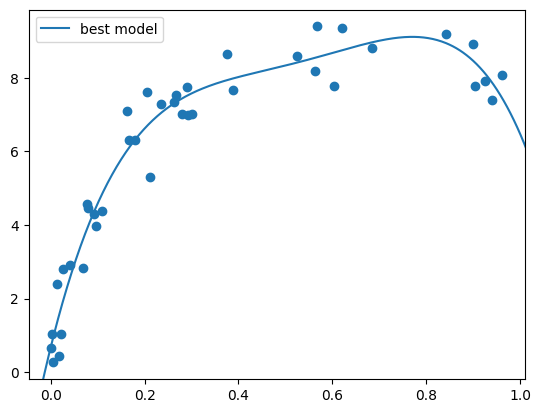

In [22]:
model = grid.best_estimator_

fig, ax = plt.subplots()
ax.scatter(X.ravel(), y)

limits = ax.axis()
y_test = model.fit(X, y).predict(X_test)
ax.plot(X_test.ravel(), y_test, label="best model")
ax.axis(limits)
ax.legend(loc="best")


Grid search даёт и другие возможности: можно задать собственную функцию оценки, распараллелить вычисления, выполнять случайный поиск и многое другое. Подробнее смотрите в [документации Scikit-Learn по grid search](https://scikit-learn.org/stable/modules/grid_search.html).

## Итог

В этом разделе мы начали разбирать идею валидации модели и оптимизации гиперпараметров, делая акцент на интуитивном понимании компромисса *bias–variance* и того, как он проявляется при подгонке моделей к данным. В частности, мы увидели, что использование валидационной выборки или кросс-валидации критически важно при настройке параметров, чтобы избежать переобучения у более сложных и гибких моделей.